In [1]:
import geopy.distance
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rc, colors
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap,Normalize
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
#import cmweather
import seaborn as sns
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import interp2d, RectBivariateSpline
from datetime import datetime, timedelta
import cftime
import json
import glob
import os
from orcestra import get_flight_segments
from orcestra.flightplan import sal, tbpb
import fsspec
import ipfsspec

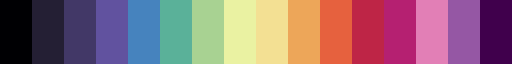

In [2]:
def load_colormap_from_txt(file_path):
    # Load RGB values from the file
    rgb_values = np.loadtxt(file_path)
    return ListedColormap(rgb_values)

# Example usage
colormap_file = 'chase-spectral-rgb.txt'  # Replace with your .txt file path
radar_cmap = load_colormap_from_txt(colormap_file)

discrete_cmap = ListedColormap(radar_cmap(np.linspace(0, 1, 16)))
discrete_mask_cmap = discrete_cmap.copy()
discrete_mask_cmap.set_under(color='white') #set values below vmin to white
discrete_mask_cmap.set_bad(color='gray') #set missing (NaN) values to gray

discrete_mask_cmap

In [3]:
#Define time period
time_map1 = np.datetime64('2024-09-03T15:00')
time_map2 = np.datetime64('2024-09-03T15:20')

#HALO flight id
flight_id_case = 'HALO-20240903a'

In [4]:
meta = get_flight_segments()

segments = [{**s,
             "platform_id": platform_id,
             "flight_id": flight_id
            }
            for platform_id, flights in meta.items()
            for flight_id, flight in flights.items()
            for s in flight["segments"]
           ]

flight_ids = [flight_id
              for flights in meta.values()
              for flight_id in flights]
print(f"Totel number of flights: {len(flight_ids)}")

Totel number of flights: 48


In [5]:
#List available segment kinds

kinds = set(k for s in segments for k in s["kinds"])

segment_ids_by_kind = {kind: [segment["segment_id"]
                              for segment in segments
                              if kind in segment["kinds"]]
                       for kind in kinds}

In [6]:
import os
os.environ["IPFS_GATEWAY"] = "https://ipfs.orcestra-campaign.org"

In [7]:
# Grab all segments of a specific kind
def get_halo_position(freq="1s"):
    """Return the HALO position at a given time frequency."""
    # root = "ipns://latest.orcestra-campaign.org"
    root = "ipfs://QmSpviiAWcdFTRJu7UPkJePoEkK1XWZefx7ZjS5zuHNiFA"
    return (
        xr.open_dataset(f"{root}/products/HALO/position_attitude.zarr", engine="zarr")
        .reset_coords(("lat", "lon"))[["lat", "lon"]]
        .resample(time=freq)
        .mean()
        .load()
    )

def kinds2color(kinds):
    if "circle" and "atr_coordination" in kinds:
        return "C2"
    if "circle" and "meteor_coordination" in kinds:
        return "C4"
    if "circle" in kinds:
        return "C1"
    if "ec_track" and "meteor_coordioation" in kinds:
        return "C4"
    if "ec_track" in kinds:
        return "C3"
    if "meteor_coordination" in kinds:
        return "C4"
    return "C0"

In [8]:
ds_halo = get_halo_position()
kind = "meteor_coordination"
kind = "circle"
namee = "circle_mid"

for s in segments:
    #if kind in s["kinds"] and flight_id_case==s["flight_id"]:
    if kind in s["kinds"] and flight_id_case==s["flight_id"] and namee in s["name"]:
        t = slice(s["start"], s["end"])
        print("s", s)
        print("t", t)

s {'segment_id': 'HALO-20240903a_c30f', 'name': 'circle_mid', 'start': datetime.datetime(2024, 9, 3, 15, 2, 21), 'end': datetime.datetime(2024, 9, 3, 15, 57, 8), 'kinds': ['circle', 'circle_counterclockwise', 'meteor_coordination'], 'remarks': ['irregularity: turbulence 2024-09-03T15:17:40 - 2024-09-03T15:29:25', 'irregularity: turbulence 2024-09-03T15:46:16 - 2024-09-03T15:46:25'], 'clat': 8.501053096573967, 'clon': -30.840227080798226, 'radius': 129423.96511552358, 'platform_id': 'HALO', 'flight_id': 'HALO-20240903a'}
t slice(datetime.datetime(2024, 9, 3, 15, 2, 21), datetime.datetime(2024, 9, 3, 15, 57, 8), None)


In [9]:
os.environ["IPFS_GATEWAY"] = "https://ipfs.orcestra-campaign.org"

cid = "bafybeigmd3dovwm45ylfqxnn2jphsrdjl2jt3dfytv7grkyhleaq42jthe"
mapper = fsspec.get_mapper(f"ipfs://{cid}")
ds_halo_radar = xr.open_zarr(mapper, consolidated=True)

In [10]:
# Load HALO radar for the circle time
halo_circle = ds_halo_radar.sel(time=slice("2024-09-03T15:00:00", "2024-09-03T16:20:00"))

# Get lat/lon from ds_halo (position dataset you already have)
halo_pos = ds_halo.sel(time=slice("2024-09-03T15:00:00", "2024-09-03T16:20:00"))
track_lat = np.asarray(halo_pos.lat.values)
track_lon = np.asarray(halo_pos.lon.values)
track_time = halo_pos.time.values

# Max dBZg from 100-4500m
Z = halo_circle["dBZg"].where(halo_circle["dBZg"] > -300)
Z_max = Z.sel(height=slice(100, 4500)).max(dim="height", skipna=True)

# Interpolate Z_max to match position times
Z_max_interp = Z_max.interp(time=halo_pos.time)
zmax_vals = np.asarray(Z_max_interp.values)

# Filter good points
good = np.isfinite(track_lat) & np.isfinite(track_lon) & np.isfinite(zmax_vals)
track_lat = track_lat[good]
track_lon = track_lon[good]
zmax_vals = zmax_vals[good]

# Build line segments
points = np.array([track_lon, track_lat]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
segment_vals = 0.5 * (zmax_vals[:-1] + zmax_vals[1:])

In [11]:
#Circle reflectivity file along with the velocity
#Composite data 
circle = xr.open_dataset('./processed_data/gridded_composite_20240903_1500.nc')
map = circle.DBZ[0,:,:]
grid_vel = circle.VEL[0,:,:]

#gridded volume data 
circle_vol = xr.open_dataset('./processed_data/gridded_volume_20240903_1500.nc')
map_vol = circle_vol.DBZ[0,:,:]
vol_vel = circle_vol.VEL[0, 0, :, :]

In [12]:
radius = 120  # km
distances = np.sqrt((map_vol.latitude - map_vol.latitude[120, 120])**2 + (map_vol.longitude - map_vol.longitude[120, 120])**2) * 111.32  # Approximate conversion from degrees to km
map_vol = map_vol.where(distances<=radius,np.nan)  # Set values outside the radius to NaN

In [13]:
# set to nan outside of radius 120 km to only include data with the 3D volume, convert degrees to km 
radius = 120  
distances = np.sqrt((map_vol.latitude - map_vol.latitude[120, 120])**2 + (map_vol.longitude - map_vol.longitude[120, 120])**2) * 111.32 
map_vol = map_vol.where(distances<=radius,np.nan)  # Set values outside the radius to NaN

In [14]:
#find the maximum height where the reflectivity is above a threshold
threshold = 10

# mask for valid data
valid_data = ~np.isnan(map_vol.values)

# mask for reflectivity above threshold
above_thresh = valid_data & (map_vol.values >= threshold)

# Find the highest height where above thresh is True for each (y, x), if not found return -1
max_indices = np.where(above_thresh.any(axis=0), above_thresh.shape[0] - 1 - np.argmax(above_thresh[::-1], axis=0), -1)

# Initialize output: NaN where no valid data, -5 where threshold not met
echo_top_height = np.full(map_vol.shape[1:], np.nan)
has_valid = valid_data.any(axis=0)
echo_top_height[has_valid] = -5

# Set echo top height where threshold is met
valid = max_indices != -1
echo_top_height[valid] = map_vol.Z.values[max_indices[valid].astype(int)]

In [15]:
# root = "ipns://latest.orcestra-campaign.org" dropsonde data 
root = "ipfs://QmSpviiAWcdFTRJu7UPkJePoEkK1XWZefx7ZjS5zuHNiFA"
drops = xr.open_dataset(f"{root}/products/HALO/dropsondes/Level_3/PERCUSION_Level_3.zarr", engine="zarr")

In [16]:
drops_times = pd.to_datetime(drops.launch_time.values)

# Find indices within the time slice t
mask = (drops_times >= pd.to_datetime(t.start)) & (drops_times <= pd.to_datetime(t.stop))

# Select dropsondes within the time slice
drops_case = drops.isel(sonde=mask)

In [17]:
# root = "ipns://latest.orcestra-campaign.org" radiosonde data
root = "ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4."
ds_radiosondes = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")

ds_radiosondes.sel(launch_time=slice('2024-09-03T15:00', '2024-09-03T16:30'))
radio_case = ds_radiosondes.sel(launch_time=slice('2024-09-03T15:05', '2024-09-03T16:30'))

In [18]:
from matplotlib.colors import LinearSegmentedColormap

# Colormap
vel_cmap = LinearSegmentedColormap.from_list('redgreen', ['darkred', 'white', 'darkgreen'], N=256)
vel_cmap.set_bad(color='gray')
vel_cmap.set_under(color='white')

vel_masked = grid_vel.where(map.notnull())

# Mask outside outer circle
lon2d = map.longitude.values
lat2d = map.latitude.values
center_lon = map.longitude[245, 245].values
center_lat = map.latitude[245, 245].values
dist = np.sqrt(((lon2d - center_lon) * 111.32)**2 + ((lat2d - center_lat) * 111.32)**2)
outside_circle = dist > 240

In [19]:
# Compute mean u and v components of dropsondes 
mean_u = drops_case.u.mean(dim='sonde')
mean_v = drops_case.v.mean(dim='sonde')
mean_wspd_uv = np.sqrt(mean_u**2 + mean_v**2)

# Std of u/v  wind speed
ind_wspd_uv = np.sqrt(drops_case.u**2 + drops_case.v**2)
std_wspd_uv = ind_wspd_uv.std(dim='sonde')

# Mean wind direction from u/v
mean_wdir_uv = (np.degrees(np.arctan2(-mean_u, -mean_v)) % 360)

# Select every 0.5 km for barbs
alt_barb = np.arange(0, drops_case.altitude.max().values/1000, 0.5)
alt_m = alt_barb * 1000

mean_wspd_uv_barb = mean_wspd_uv.sel(altitude=alt_m, method='nearest')
mean_wdir_uv_barb = mean_wdir_uv.sel(altitude=alt_m, method='nearest')


def wdir_wspd_to_uv(wdir, wspd):
    wdir_rad = np.radians(wdir)
    u = -wspd * np.sin(wdir_rad)
    v = -wspd * np.cos(wdir_rad)
    return u, v

#create wind barbs
u_barb_uv, v_barb_uv = wdir_wspd_to_uv(mean_wdir_uv_barb.values, mean_wspd_uv_barb.values)

/opt/anaconda3/envs/awing/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [20]:
radio_case = ds_radiosondes.sel(launch_time=slice('2024-09-03T15:05', '2024-09-03T16:30'))

#Compute u and v components of radiosondes 
mean_u = radio_case.u.mean(dim='launch_time')
mean_v = radio_case.v.mean(dim='launch_time')
mean_wspd_uv = np.sqrt(mean_u**2 + mean_v**2)
mean_wdir_uv = (np.degrees(np.arctan2(-mean_u, -mean_v)) % 360)

# Std
ind_wspd_uv = np.sqrt(radio_case.u**2 + radio_case.v**2)
std_wspd_uv = ind_wspd_uv.std(dim='launch_time')

# Barbs every 0.5 km up to 15 km
alt_barb = np.arange(0, 15, 0.5)
alt_m = alt_barb * 1000

mean_wspd_uv_barb = mean_wspd_uv.sel(height=alt_m, method='nearest')
mean_wdir_uv_barb = mean_wdir_uv.sel(height=alt_m, method='nearest')

u_barb_uv, v_barb_uv = wdir_wspd_to_uv(mean_wdir_uv_barb.values, mean_wspd_uv_barb.values)

/opt/anaconda3/envs/awing/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/var/folders/ym/zbw7d2hd013cdrqzhhl0z7580000gn/T/ipykernel_26642/3125165208.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p1 = axs[0].pcolormesh(map.longitude, map.latitude, map,
/var/folders/ym/zbw7d2hd013cdrqzhhl0z7580000gn/T/ipykernel_26642/3125165208.py:57: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p2 = axs[1].pcolormesh(grid_vel.longitude, grid_vel.latitude, vel_masked,
/opt/anaconda3/envs/awing/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof

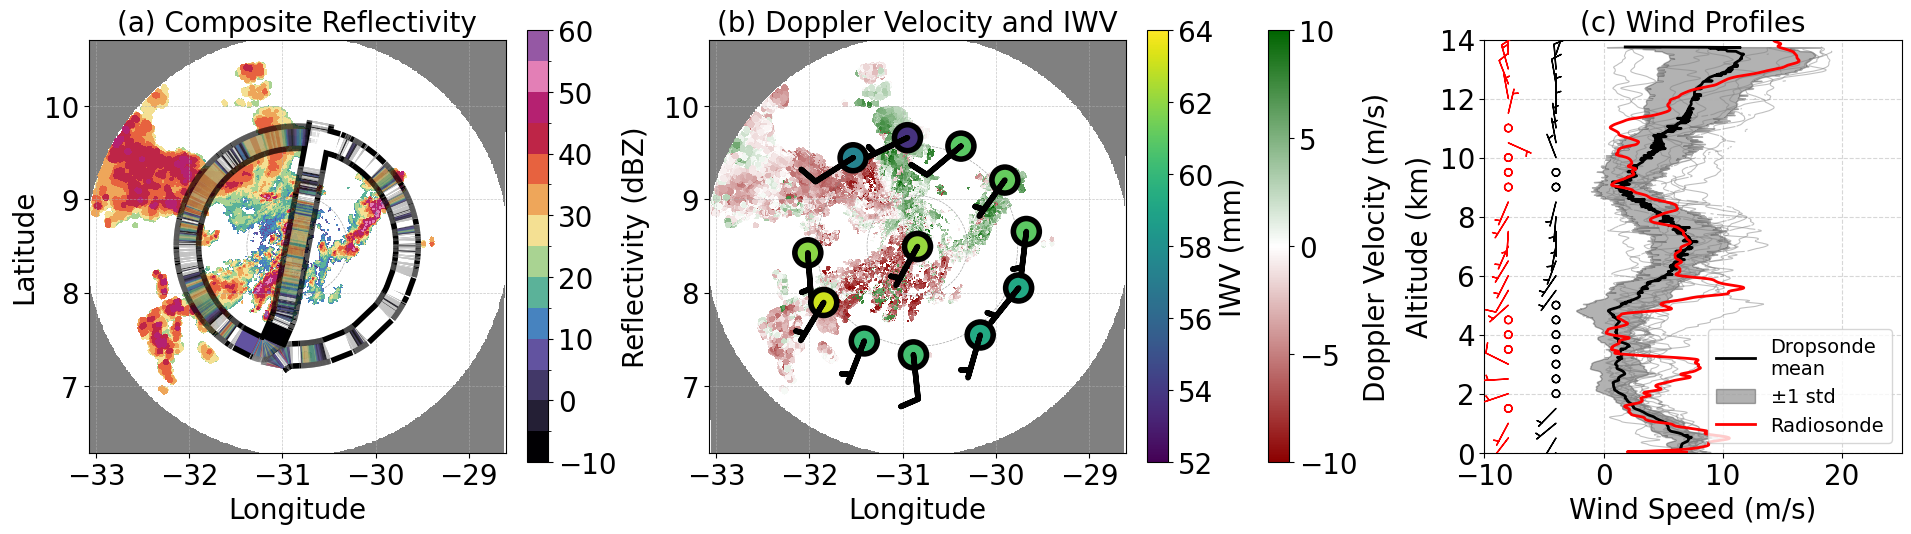

In [38]:
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm

# center of the map for the plot
center_lon = map.longitude[245,245].values
center_lat = map.latitude[245,245].values

#radar levels
levels = np.linspace(-10, 60, 15)
levels_ticks = np.linspace(-10, 60, 8)

#colormaps 
#turbo_cmap = plt.cm.turbo.copy()
#turbo_cmap.set_under(color='white')
#turbo_cmap.set_bad(color='gray')
#norm = BoundaryNorm(levels, ncolors=turbo_cmap.N, clip=False)
norm = BoundaryNorm(levels, ncolors=discrete_mask_cmap.N, clip=False)

# fontsizs, CBL = Colorbar label, CBT = Colorbar ticks, LEG = Legend
LABEL=20; TICK=20; TITLE=20; CBL=20; CBT=20; LEG=14

# identical box shape for all three panels so they allign  
lon_range = float(map.longitude.max() - map.longitude.min())
lat_range = float(map.latitude.max() - map.latitude.min())
BOX = lat_range / lon_range

fig, axs = plt.subplots(1, 3, figsize=(19, 6), layout='constrained')
for ax in axs:
    ax.set_box_aspect(BOX)

#Reflectivity plot 
p1 = axs[0].pcolormesh(map.longitude, map.latitude, map,
                       cmap=discrete_mask_cmap, norm=norm, shading='auto')
cbar_a = fig.colorbar(p1, ax=axs[0], shrink=0.73)
cbar_a.set_ticks(levels_ticks)
cbar_a.ax.tick_params(labelsize=CBT)
cbar_a.set_label('Reflectivity (dBZ)', fontsize=CBL)

lc_outline = LineCollection(segments, colors='black', linewidth=20, zorder=2)
axs[0].add_collection(lc_outline)
lc = LineCollection(segments, cmap=discrete_mask_cmap, norm=norm, linewidth=12, zorder=3)
lc.set_array(segment_vals)
axs[0].add_collection(lc)

axs[0].add_patch(plt.Circle((center_lon, center_lat), 120/111.32, color='gray', alpha=0.7, fill=False, linestyle='--', linewidth=0.5))
axs[0].add_patch(plt.Circle((center_lon, center_lat), 60/111.32, color='gray', alpha=0.7, fill=False, linestyle='--', linewidth=0.5))
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0].set_xlim([map.longitude.min(), map.longitude.max()])
axs[0].set_ylim([map.latitude.min(), map.latitude.max()])
axs[0].set_xlabel('Longitude', fontsize=LABEL)
axs[0].set_ylabel('Latitude', fontsize=LABEL)
axs[0].tick_params(axis='both', labelsize=TICK)
axs[0].set_title('(a) Composite Reflectivity', fontsize=TITLE)


# Velocity 
p2 = axs[1].pcolormesh(grid_vel.longitude, grid_vel.latitude, vel_masked,
                       cmap=vel_cmap, vmin=-10, vmax=10, shading='auto')
cbar_b = fig.colorbar(p2, ax=axs[1], shrink=0.73)
cbar_b.set_ticks(np.linspace(-10, 10, 5))
cbar_b.ax.tick_params(labelsize=CBT)
cbar_b.set_label('Doppler Velocity (m/s)', fontsize=CBL)

#scatter for dropssonde 
sc = axs[1].scatter(drops_case.launch_lon, drops_case.launch_lat, c=drops_case.iwv,
                    cmap='viridis', s=350, edgecolors='k', zorder=4, linewidth=4,vmin=52, vmax=64)
sc_radio2 = axs[1].scatter(radio_case.launch_lon, radio_case.launch_lat, c=radio_case.iwv,
                           cmap='viridis', s=350, edgecolors='k', zorder=4, marker='o',
                           vmin=52, vmax=64, linewidth=4)
cbar_iwv = fig.colorbar(sc, ax=axs[1], shrink=0.73)
cbar_iwv.ax.tick_params(labelsize=CBT)
cbar_iwv.set_label('IWV (mm)', fontsize=CBL)

# Dropsonde wind barbs at 10 m pulled from the wspd and wdir variable (could use the u and v components as well)
wspd_10m_drop = drops_case.wspd.sel(altitude=10, method='nearest').values
wdir_10m_drop = drops_case.wdir.sel(altitude=10, method='nearest').values

u_drop_10m = -wspd_10m_drop * np.sin(np.radians(wdir_10m_drop))
v_drop_10m = -wspd_10m_drop * np.cos(np.radians(wdir_10m_drop))
axs[1].barbs(drops_case.launch_lon.values, drops_case.launch_lat.values,
             u_drop_10m, v_drop_10m, length=8, color='black', zorder=5, linewidth=4)


# Radiosonde wind barbs at 10 m pulled from the wspd and wdir variable (could use the u and v components as well)
wspd_10m_radio = radio_case.wspd.sel(height=10, method='nearest').values
wdir_10m_radio = radio_case.wdir.sel(height=10, method='nearest').values
u_radio_10m = -wspd_10m_radio * np.sin(np.radians(wdir_10m_radio))
v_radio_10m = -wspd_10m_radio * np.cos(np.radians(wdir_10m_radio))
axs[1].barbs(radio_case.launch_lon.values, radio_case.launch_lat.values,
             u_radio_10m, v_radio_10m, length=8, color='black', zorder=5, linewidth=4)

axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axs[1].add_patch(plt.Circle((center_lon, center_lat), 120/111.32, color='gray', alpha=0.7, fill=False, linestyle='--', linewidth=0.5))
axs[1].add_patch(plt.Circle((center_lon, center_lat), 60/111.32, color='gray', alpha=0.7, fill=False, linestyle='--', linewidth=0.5))
axs[1].set_xlim([map.longitude.min(), map.longitude.max()])
axs[1].set_ylim([map.latitude.min(), map.latitude.max()])
axs[1].set_xlabel('Longitude', fontsize=LABEL)
axs[1].tick_params(axis='both', labelsize=TICK)
axs[1].set_title('(b) Doppler Velocity and IWV', fontsize=TITLE)

# vertical wind profiles 
for i in range(len(drops_case.sonde)):
    axs[2].plot(drops_case.wspd.isel(sonde=i), drops_case.altitude/1000,
                color='gray', alpha=0.5, linewidth=0.8)

#Calculate the mean u and v componets for the vertical profile of speed, and direction
mean_u_drop = drops_case.u.mean(dim='sonde')
mean_v_drop = drops_case.v.mean(dim='sonde')
mean_wspd_uv_drop = np.sqrt(mean_u_drop**2 + mean_v_drop**2)
std_wspd_uv_drop  = np.sqrt(drops_case.u**2 + drops_case.v**2).std(dim='sonde')
mean_wdir_uv_drop = (np.degrees(np.arctan2(-mean_u_drop, -mean_v_drop)) % 360)

axs[2].plot(mean_wspd_uv_drop, drops_case.altitude/1000, color='black', linewidth=2, label='Dropsonde\nmean')
axs[2].fill_betweenx(drops_case.altitude/1000,
                     mean_wspd_uv_drop - std_wspd_uv_drop,
                     mean_wspd_uv_drop + std_wspd_uv_drop,
                     color='black', alpha=0.3, label='±1 std')

#Adding barbs along the left side of thge vertical profile panel
alt_barb_drop = np.arange(0, drops_case.altitude.max().values/1000, 0.5)
alt_m_drop = alt_barb_drop * 1000
mean_wspd_uv_drop_barb = mean_wspd_uv_drop.sel(altitude=alt_m_drop, method='nearest')
mean_wdir_uv_drop_barb = mean_wdir_uv_drop.sel(altitude=alt_m_drop, method='nearest')
u_barb_drop, v_barb_drop = wdir_wspd_to_uv(mean_wdir_uv_drop_barb.values, mean_wspd_uv_drop_barb.values)
axs[2].barbs(np.full_like(alt_barb_drop, -4), alt_barb_drop, u_barb_drop, v_barb_drop,
             length=6, color='black', zorder=5)

for i in range(len(radio_case.launch_time)):
    axs[2].plot(radio_case.wspd.isel(launch_time=i), radio_case.height/1000,
                color='red', alpha=0.5, linewidth=0.8)

mean_u_radio = radio_case.u.mean(dim='launch_time')
mean_v_radio = radio_case.v.mean(dim='launch_time')
mean_wspd_uv_radio = np.sqrt(mean_u_radio**2 + mean_v_radio**2)
std_wspd_uv_radio  = np.sqrt(radio_case.u**2 + radio_case.v**2).std(dim='launch_time')
mean_wdir_uv_radio = (np.degrees(np.arctan2(-mean_u_radio, -mean_v_radio)) % 360)

axs[2].plot(mean_wspd_uv_radio, radio_case.height/1000, color='red', linewidth=2, label='Radiosonde')

alt_barb_radio = np.arange(0, 14, 0.5)
alt_m_radio = alt_barb_radio * 1000
mean_wspd_uv_radio_barb = mean_wspd_uv_radio.sel(height=alt_m_radio, method='nearest')
mean_wdir_uv_radio_barb = mean_wdir_uv_radio.sel(height=alt_m_radio, method='nearest')
u_barb_radio, v_barb_radio = wdir_wspd_to_uv(mean_wdir_uv_radio_barb.values, mean_wspd_uv_radio_barb.values)
axs[2].barbs(np.full_like(alt_barb_radio, -8), alt_barb_radio, u_barb_radio, v_barb_radio,
             length=6, color='red', zorder=5)

axs[2].set_xlim(-10, 25)
axs[2].set_ylim(0, 14)
axs[2].set_xlabel('Wind Speed (m/s)', fontsize=LABEL)
axs[2].set_ylabel('Altitude (km)', fontsize=LABEL)
axs[2].tick_params(axis='both', labelsize=TICK)
axs[2].legend(fontsize=LEG, loc='lower right')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].set_title('(c) Wind Profiles', fontsize=TITLE)

plt.savefig('./figures/Fig_Seapol_HALO.pdf', bbox_inches='tight', dpi=200)